In [1]:
import torch, os, sys
sys.path.append('..')
from src.my_app import UNet, PreTrainDataset_v1 
import torchvision.transforms as transforms

# モデルを定義

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(3, 4).to(device)

checkpoint_path = '../checkpoints/latest_checkpoint_V1.1.pth'
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
start_epoch, best_test_loss, train_loss_history, test_loss_history = model.load_check_point(checkpoint_path, optimizer)


[MyUnet]: チェックポイントを読み込みました（エポック 100）


# データセットを定義

In [17]:
# --- Dataset ---
transform = transforms.Compose([
    # transforms.Resizeze((128, 128)),
    transforms.ToTensor()
])
test_doc_id_list = ['100241706', '100249371', '100249376', '100249416', '100249476', '100249537', '200003076', '200003803', '200003967', '200004107']
dataset = PreTrainDataset_v1(
    input_path='../../kuzushiji-recognition/synthetic_images/input_images/',
    json_path='../../kuzushiji-recognition/synthetic_images/gt_json.json',
    test_doc_id_list=test_doc_id_list,
    test_mode=False,
    precompute_gt=False,
    transform=transform,
)
dataloader = PreTrainDataset_v1.create_optimized_dataloader_for_old_dataset(
    dataset=dataset,
    batch_size=1,
    num_workers=4
)

[MyDataset_v1]: json データを読み込みました。


In [18]:
data_iter = iter(dataloader)
image = next(data_iter)[0]

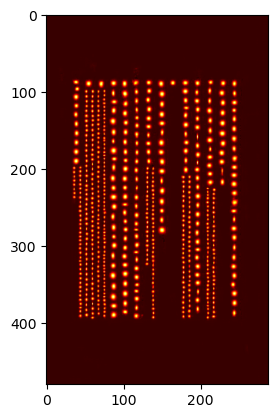

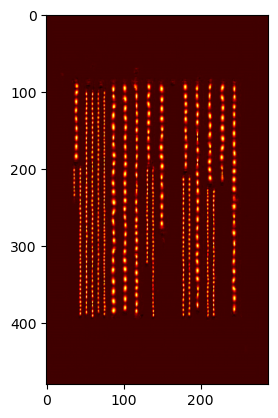

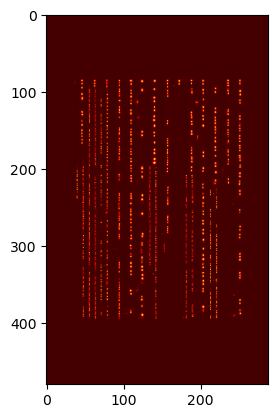

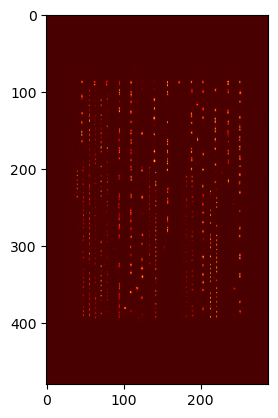

In [19]:
from matplotlib import pyplot as plt
pred = model(image)
for i in range(4):
    plt.imshow(pred[0][i].cpu().detach().numpy(), cmap='hot')
    plt.show()